## Methode STIT de Klatt et Lotz


Persistence of asymptotic variance under transport: \
from hyperfluctuation to stealthy hyperuniformity \

cf Page 6 du papier:
https://arxiv.org/pdf/2605.22803


 STIT tessellations = STable with respect to ITerations

In [1]:
!pip install --upgrade blue_sampler

In [2]:
import blue_sampler as blue
import numpy as np

## fair STIT allow to sample 1 million tessels in a matter of seconds
Here we show only the first tesselation steps

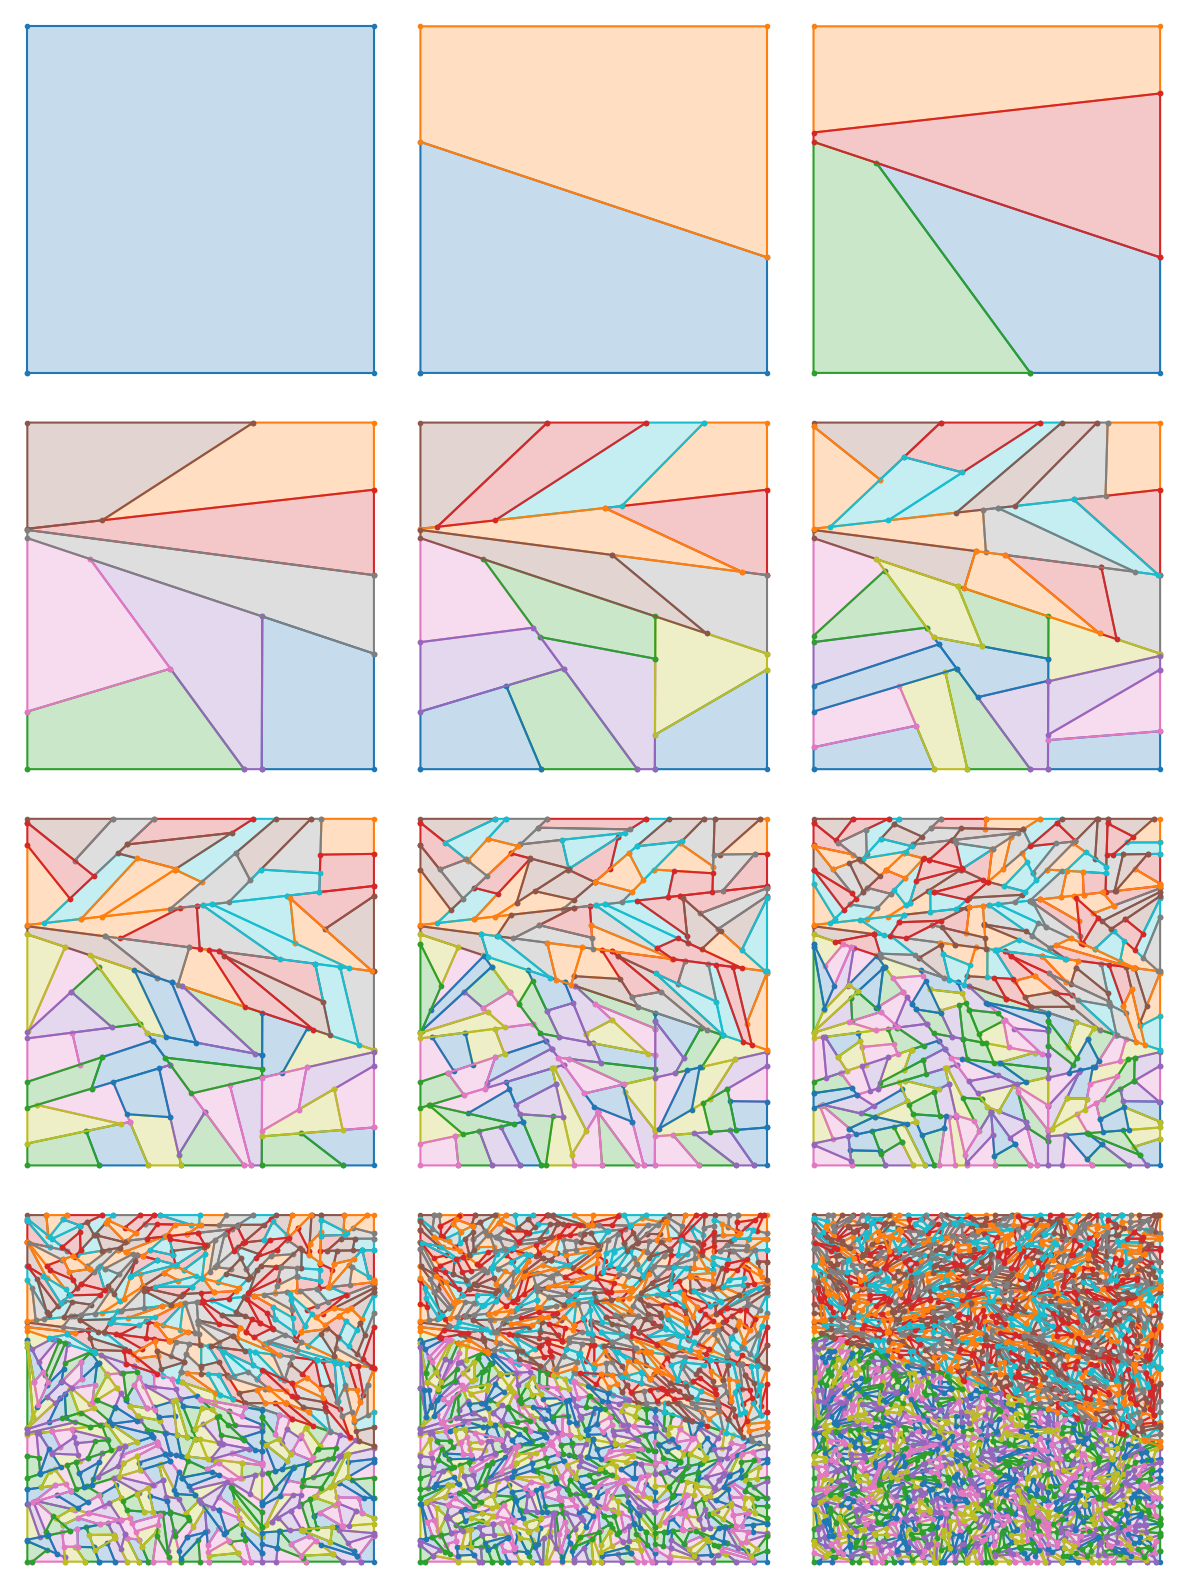

In [3]:
quad = blue.sample_tessels(N = 2**20)

## Now we can sample points well distributed with respect to the tessels


Here we just sample points at the center of each tessel

In [4]:
x = quad.mean(axis = 1)
print(x.shape)

(1048576, 2)


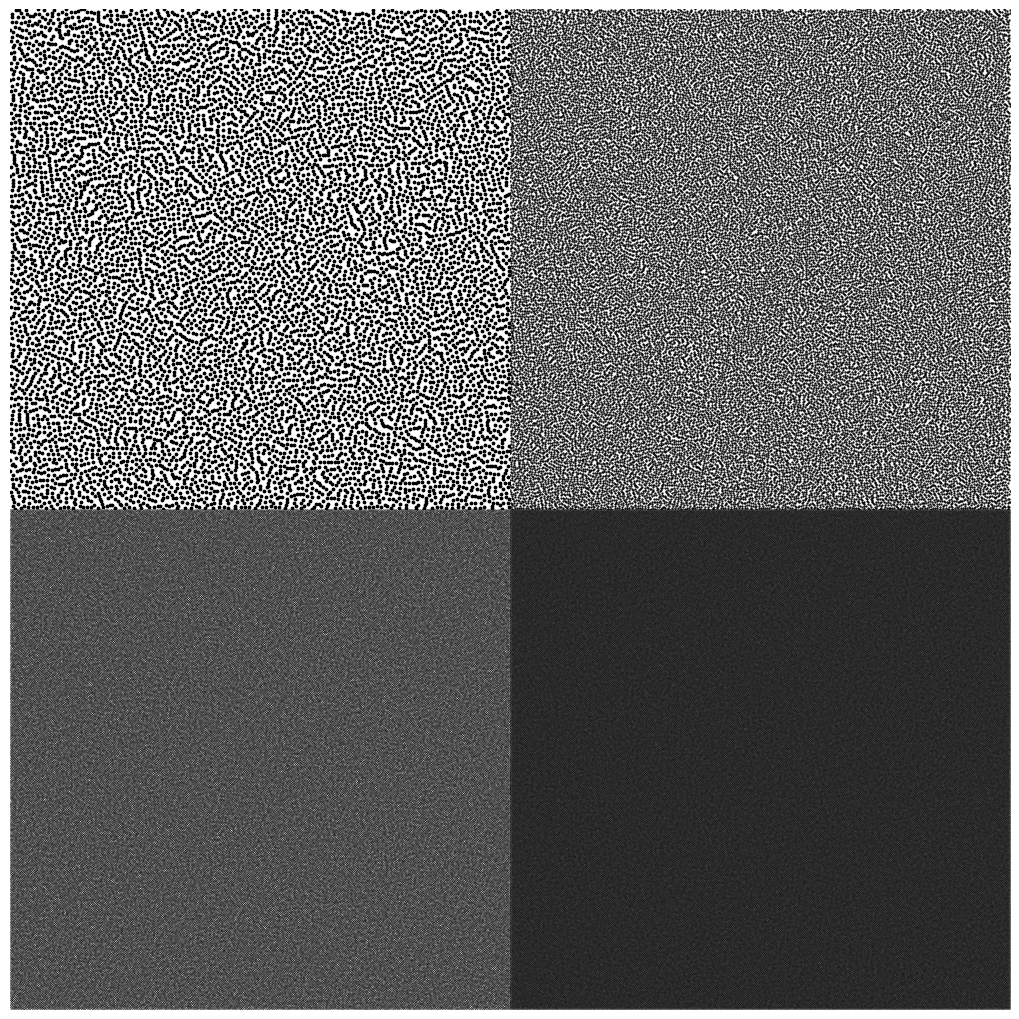

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=False)

zooms = [0.1, 0.2, 0.5, 1.0]
for ax, zoom in zip(axes.flatten(), zooms):
    xzoom = x[(x <= zoom).all(axis=-1)]
    ax.scatter(xzoom[:, 0], xzoom[:, 1], color="black", s=0.003 / zoom**3)
    ax.axis("off")
for ax in axes.flatten():
    ax.set_axis_off()
    ax.margins(0)

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)
plt.show()

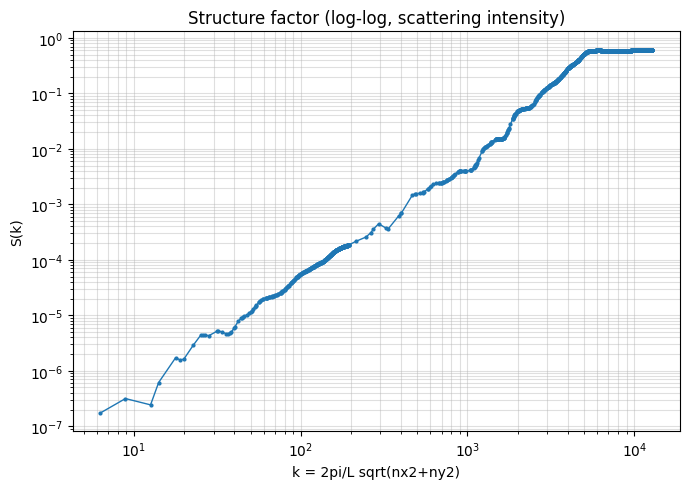

In [6]:
_ = blue.plot_structure_factor(x, resolution = 1)

## Tessels for adaptative sampling

In [9]:
from blue_sampler.datasets import generate_dataset

source: squarenet.sampler from module squarenet
available datasets: {'realdata': ['barbara', 'lena', 'france', 'germany', 'everest'], 'synthetic': ['square', 'ball', 'ring', 'gaussian', 'spiky', 'holy', '4Dloop']}


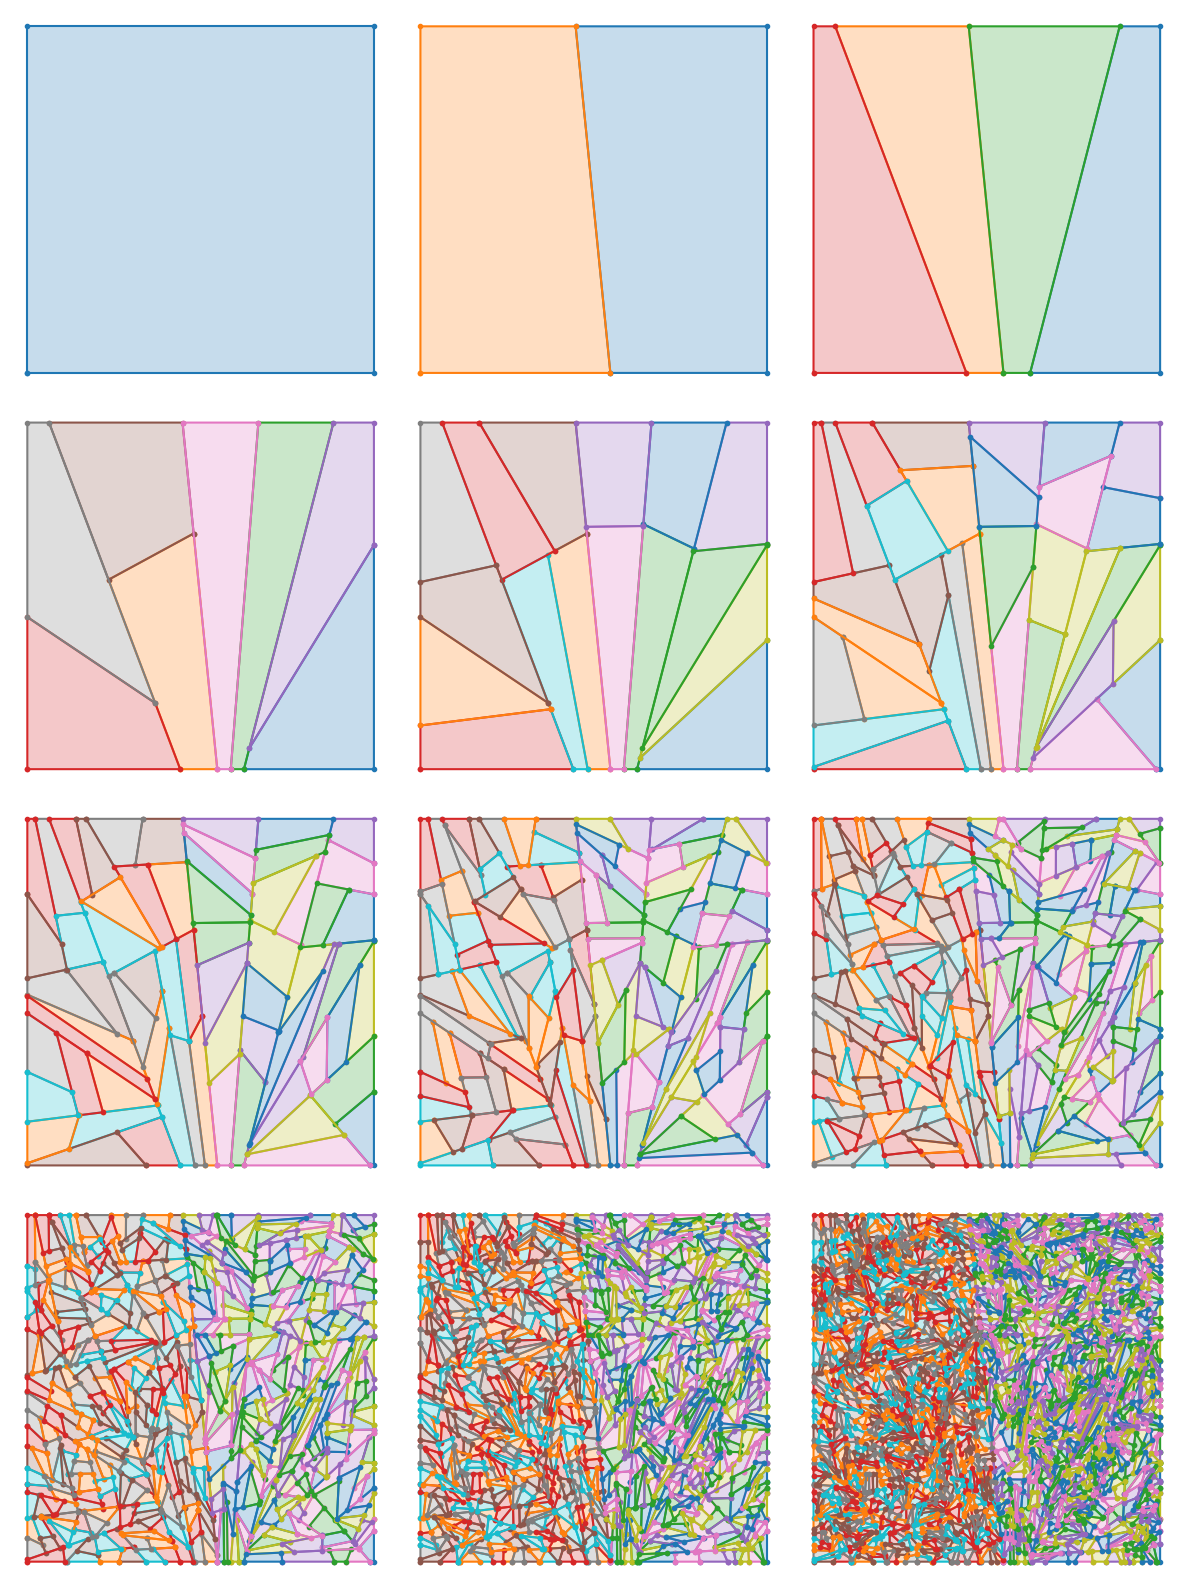

In [16]:
N = 1024*32
K = N * 100
targets = generate_dataset(method = "barbara", size = (K, 2), plot_points = False)
tessels, _ = blue.sample_tessels(N =N, targets = targets, display = True)

## Here comes the magic

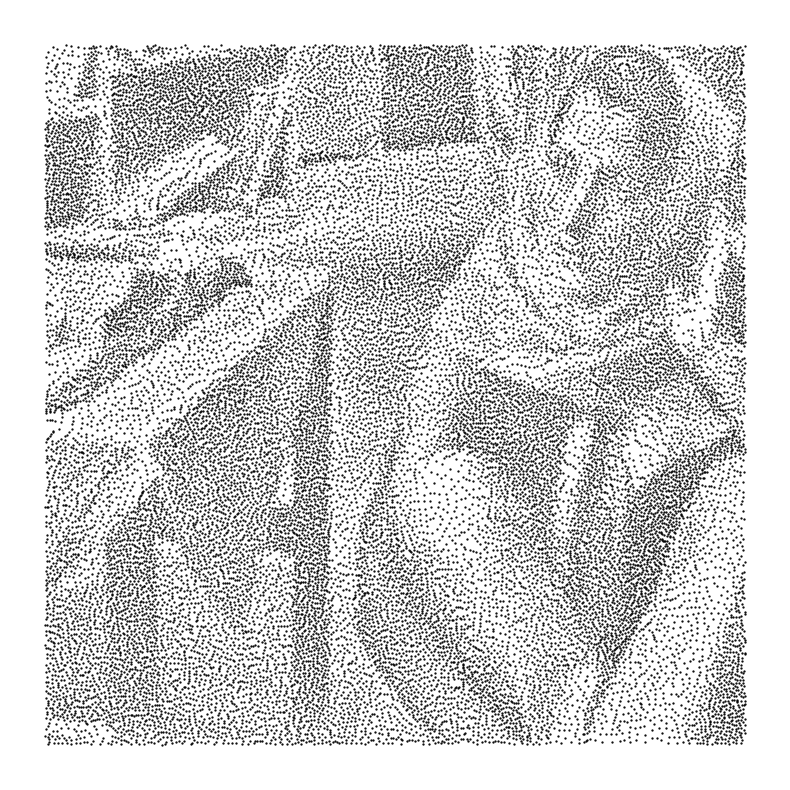

In [17]:
x = tessels.mean(axis = 1)
_ = blue.plot(x)